# scatter — GPU-accelerated scatter plot

Renders circles via the SDF pipeline. Handles millions of points.

```
scatter(x_or_data, y=None, *, x_col, y_col, color, size, opacity,
        width, height, padding, layers, interactive) -> np.ndarray | None
```

Returns an RGBA `uint8` array of shape `(height, width, 4)`.

In [1]:
import numpy as np
from PIL import Image
from IPython.display import display
import justviz as jv

## 1 — Basic scatter (array input)

scatter: 5,000 points, 800×600, render 213.2ms


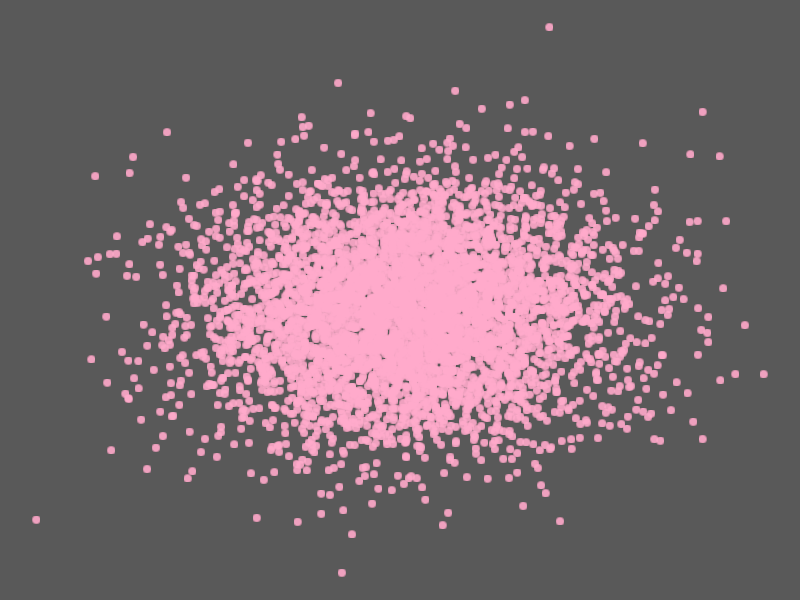

In [2]:
rng = np.random.default_rng(42)
x = rng.normal(50, 15, 5_000).astype(np.float32)
y = rng.normal(50, 15, 5_000).astype(np.float32)

img = jv.scatter(x, y, color=(1.0, 0.4, 0.6), size=4.0, opacity=0.85, width=800, height=600)
display(Image.fromarray(img, mode='RGBA'))

## 2 — 1M points, small dots

scatter: 1,000,000 points, 1024×768, render 225.1ms


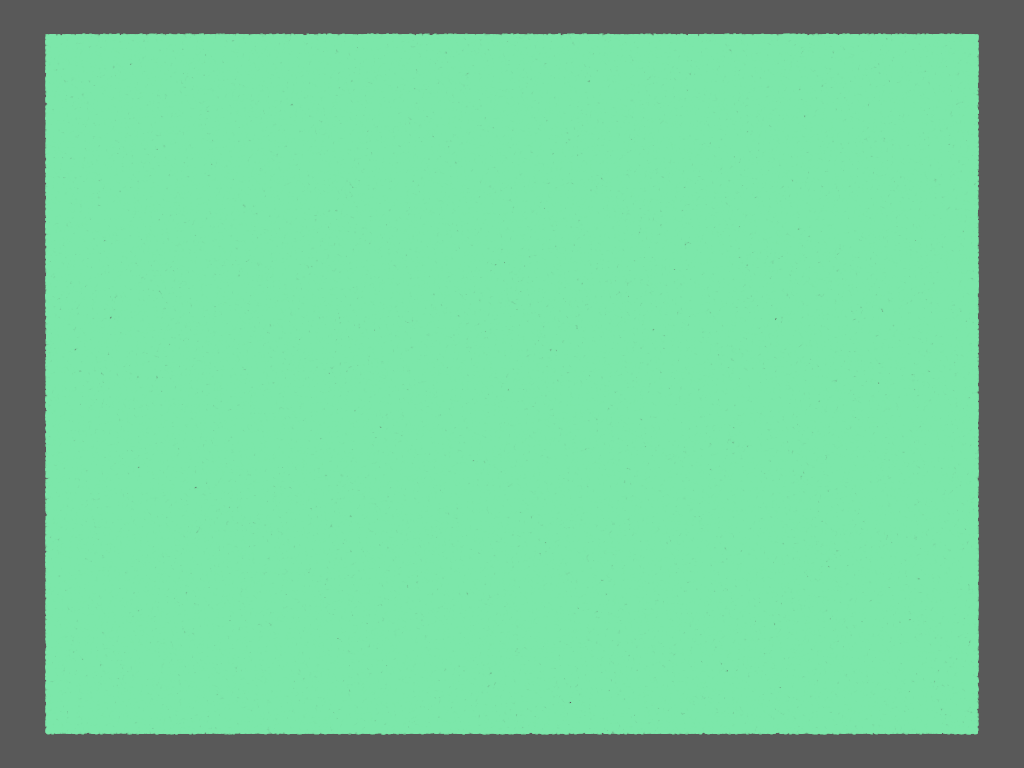

In [4]:
rng = np.random.default_rng(0)
x1m = rng.uniform(0, 100, 1_000_000).astype(np.float32)
y1m = rng.uniform(0, 100, 1_000_000).astype(np.float32)

img = jv.scatter(x1m, y1m, color=(0.2, 0.8, 0.4), size=1.5, opacity=0.6, width=1024, height=768)
display(Image.fromarray(img, mode='RGBA'))

## 3 — Multi-layer scatter

Pass `layers` as a list of dicts. Each layer can have its own `color`, `size`, and `opacity`.

scatter: 300,000 points (3 layers), 1024×768, render 80.5ms


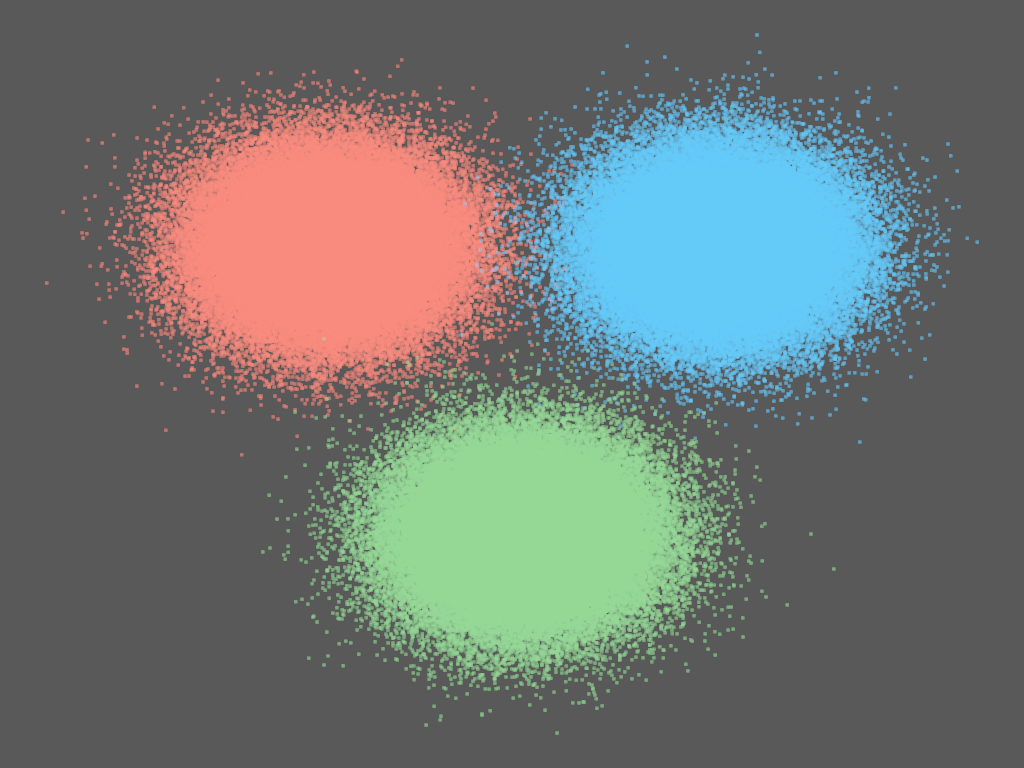

In [5]:
rng = np.random.default_rng(7)

# Three clusters at different positions
clusters = [
    {"center": (25, 25), "color": (0.95, 0.26, 0.21)},
    {"center": (75, 25), "color": (0.13, 0.59, 0.95)},
    {"center": (50, 75), "color": (0.30, 0.69, 0.31)},
]

layers = []
for c in clusters:
    cx, cy = c["center"]
    layers.append({
        "x": rng.normal(cx, 8, 100_000).astype(np.float32),
        "y": rng.normal(cy, 8, 100_000).astype(np.float32),
        "color": c["color"],
        "size": 2.0,
        "opacity": 0.5,
    })

img = jv.scatter(None, None, layers=layers, width=1024, height=768)
display(Image.fromarray(img, mode='RGBA'))

## 4 — From a pandas DataFrame

scatter: 20,000 points, 900×600, render 8.1ms


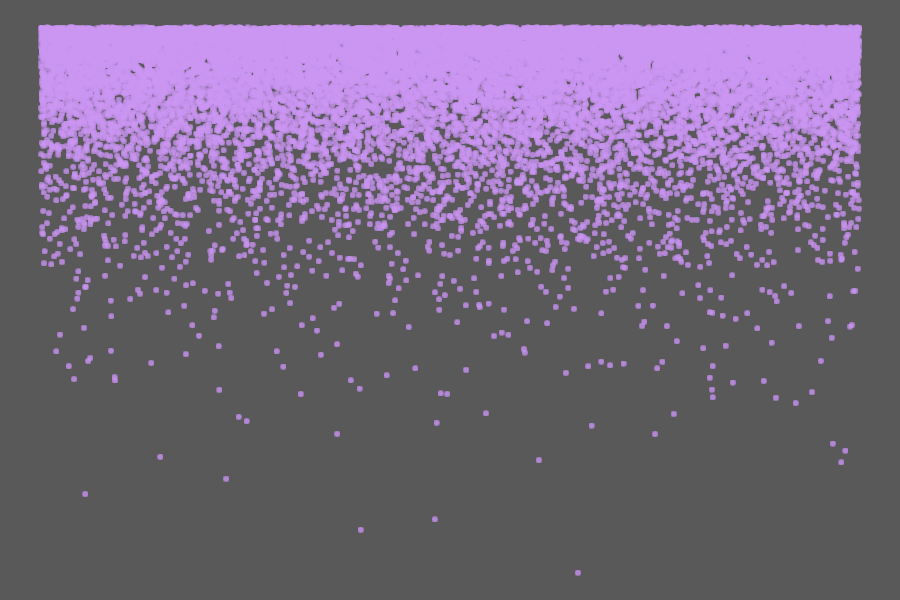

In [6]:
import pandas as pd

rng = np.random.default_rng(99)
df = pd.DataFrame({
    "price":  rng.uniform(10, 500, 20_000).astype(np.float32),
    "volume": rng.exponential(1000, 20_000).astype(np.float32),
})

img = jv.scatter(df, x_col="price", y_col="volume",
                 color=(0.6, 0.3, 0.9), size=3.0, opacity=0.7,
                 width=900, height=600)
display(Image.fromarray(img, mode='RGBA'))

## 5 — From a Parquet file

`scatter` accepts a file path string directly; it calls `dr2d.load_parquet_columns` internally.

scatter: 50,000 points, 900×600, render 15.8ms


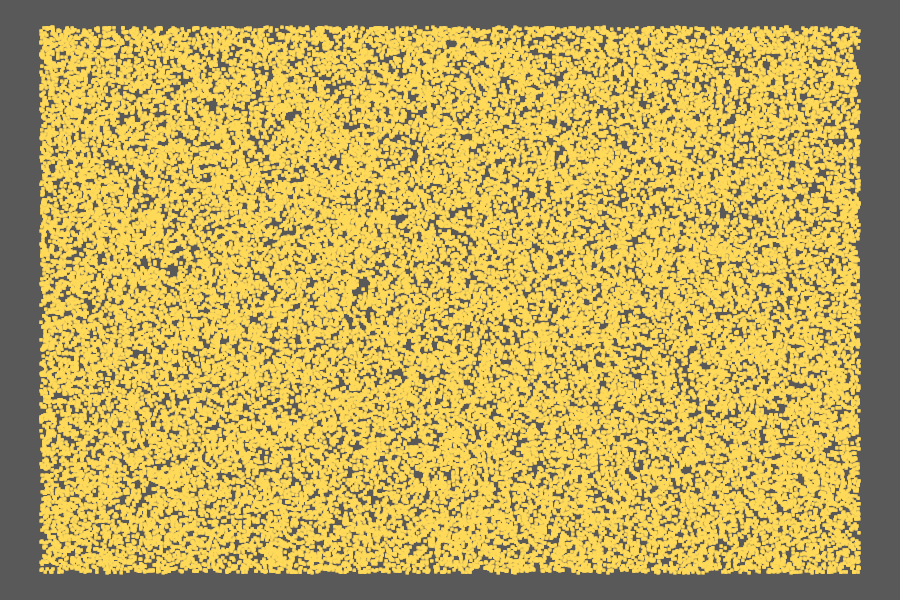

In [7]:
import pyarrow as pa
import pyarrow.parquet as pq

rng = np.random.default_rng(55)
table = pa.table({
    "lat": rng.uniform(-90, 90, 50_000).astype(np.float32),
    "lon": rng.uniform(-180, 180, 50_000).astype(np.float32),
})
pq.write_table(table, "/tmp/coords.parquet")

img = jv.scatter("/tmp/coords.parquet", x_col="lon", y_col="lat",
                 color=(1.0, 0.7, 0.1), size=2.0, width=900, height=600)
display(Image.fromarray(img, mode='RGBA'))

## 6 — Render-time benchmark

In [8]:
import time

rng = np.random.default_rng(1)
for n in [10_000, 100_000, 1_000_000, 5_000_000]:
    x = rng.uniform(0, 100, n).astype(np.float32)
    y = rng.uniform(0, 100, n).astype(np.float32)
    t0 = time.perf_counter()
    jv.scatter(x, y, color=(0.2, 0.8, 0.5), size=1.5, width=1024, height=768)
    print(f"{n/1e6:.1f}M pts: {(time.perf_counter()-t0)*1000:.0f} ms")

scatter: 10,000 points, 1024×768, render 7.9ms
0.0M pts: 9 ms
scatter: 100,000 points, 1024×768, render 34.0ms
0.1M pts: 40 ms
scatter: 1,000,000 points, 1024×768, render 207.7ms
1.0M pts: 270 ms
scatter: 5,000,000 points, 1024×768, render 1060.4ms
5.0M pts: 1352 ms
